# Comparison

## 1. Setup

> Which model's outputs are we evaluating, and how many of them are valid?

Loads the original dataset and the model's synthetic output, then checks the debug file to count how many records failed to generate, giving an immediate sense of generation reliability before any quality analysis.

In [1]:
import subprocess, os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")

MODEL_NAME = "qwen7b_lora_10_dp_16"

BASE_DIR   = "../generation/outputs"
ORIG_PATH  = "../generation/dataset/cct_ft_100pct.json"
SYNT_PATH  = os.path.join(BASE_DIR, f"{MODEL_NAME}_0.json")
DEBUG_PATH = os.path.join(BASE_DIR, f"{MODEL_NAME}_0_debug.json")

with open(ORIG_PATH) as f:
    orig = pd.DataFrame(json.load(f))

if os.path.exists(SYNT_PATH):
    with open(SYNT_PATH) as f:
        synt = pd.DataFrame(json.load(f))
else:
    synt = pd.DataFrame()

if os.path.exists(DEBUG_PATH):
    with open(DEBUG_PATH) as f:
        debug_raw = json.load(f)
    debug_entries = debug_raw if isinstance(debug_raw, list) else debug_raw.get("errors", [])
    n_errors = len(debug_entries)
else:
    debug_entries = []
    n_errors = 0

In [2]:
n_valid = len(synt)
n_total = n_valid + n_errors
pct_err = n_errors / n_total * 100 if n_total > 0 else 0

print(f"Model  : {MODEL_NAME}")
print(f"Valids   : {n_valid:>6,}  ({100 - pct_err:.2f}%)")
print(f"Errors   : {n_errors:>6,}  ({pct_err:.2f}%)")
print(f"Total   : {n_total:>6,}")

if not n_valid:
    raise FileNotFoundError("No valid synthetic data generated. Stopping comparison.")

orig["source"] = "original"
synt["source"] = "synthetic"
combined = pd.concat([orig, synt], ignore_index=True)

Model  : qwen7b_lora_10_dp_16
Valids   : 10,000  (99.99%)
Errors   :      1  (0.01%)
Total   : 10,001


## 2. Data quality

> Are the synthetic and original datasets structurally identical?

A basic null-check and shape inspection on both DataFrames, plus a descriptive statistics comparison.

In [3]:
print("=== ORIGINAL ===")
print(orig.shape)
print(orig.isnull().sum()[orig.isnull().sum() > 0])

print("\n=== SYNTHETIC ===")
print(synt.shape)
print(synt.isnull().sum()[synt.isnull().sum() > 0])

=== ORIGINAL ===
(1296675, 24)
Series([], dtype: int64)

=== SYNTHETIC ===
(10000, 24)
Series([], dtype: int64)


In [4]:
num_cols = ["amt", "lat", "long", "merch_lat", "merch_long", "city_pop", "unix_time"]

desc_orig = orig[num_cols].describe().T
desc_synt = synt[num_cols].describe().T
desc_orig.columns = ["count_o","mean_o","std_o","min_o","25_o","50_o","75_o","max_o"]
desc_synt.columns = ["count_s","mean_s","std_s","min_s","25_s","50_s","75_s","max_s"]

pd.concat([desc_orig, desc_synt], axis=1)

,count_o,mean_o,std_o,min_o,25_o,50_o,75_o,max_o,count_s,mean_s,std_s,min_s,25_s,50_s,75_s,max_s
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04,10000.0,4.943304e+01,5.236283e+01,1.010000e+00,8.520000e+00,3.169000e+01,7.501250e+01,3.529500e+02
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01,10000.0,3.857851e+01,4.847091e+00,2.121580e+01,3.480922e+01,3.967905e+01,4.171410e+01,6.479290e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01,10000.0,-8.936105e+01,1.346980e+01,-1.580562e+02,-9.513298e+01,-8.614700e+01,-8.001262e+01,-6.742210e+01
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01,10000.0,3.857060e+01,4.837560e+00,2.078082e+01,3.502906e+01,3.961863e+01,4.172700e+01,6.451888e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01,10000.0,-8.938397e+01,1.347362e+01,-1.572225e+02,-9.501774e+01,-8.617247e+01,-7.989909e+01,-6.739520e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06,10000.0,7.295371e+04,2.728811e+05,1.200000e+01,1.989750e+03,1.199900e+04,5.814650e+04,8.622698e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09,10000.0,1.351113e+09,1.277330e+07,1.325376e+09,1.340415e+09,1.351630e+09,1.362709e+09,1.372293e+09


## 3. Numerical Distributions

> Do the synthetic numerical features visually resemble the originals?

Side-by-side histograms and boxplots for each numerical column. Histograms show shape, skew and modes; boxplots expose differences in median, spread and outliers.

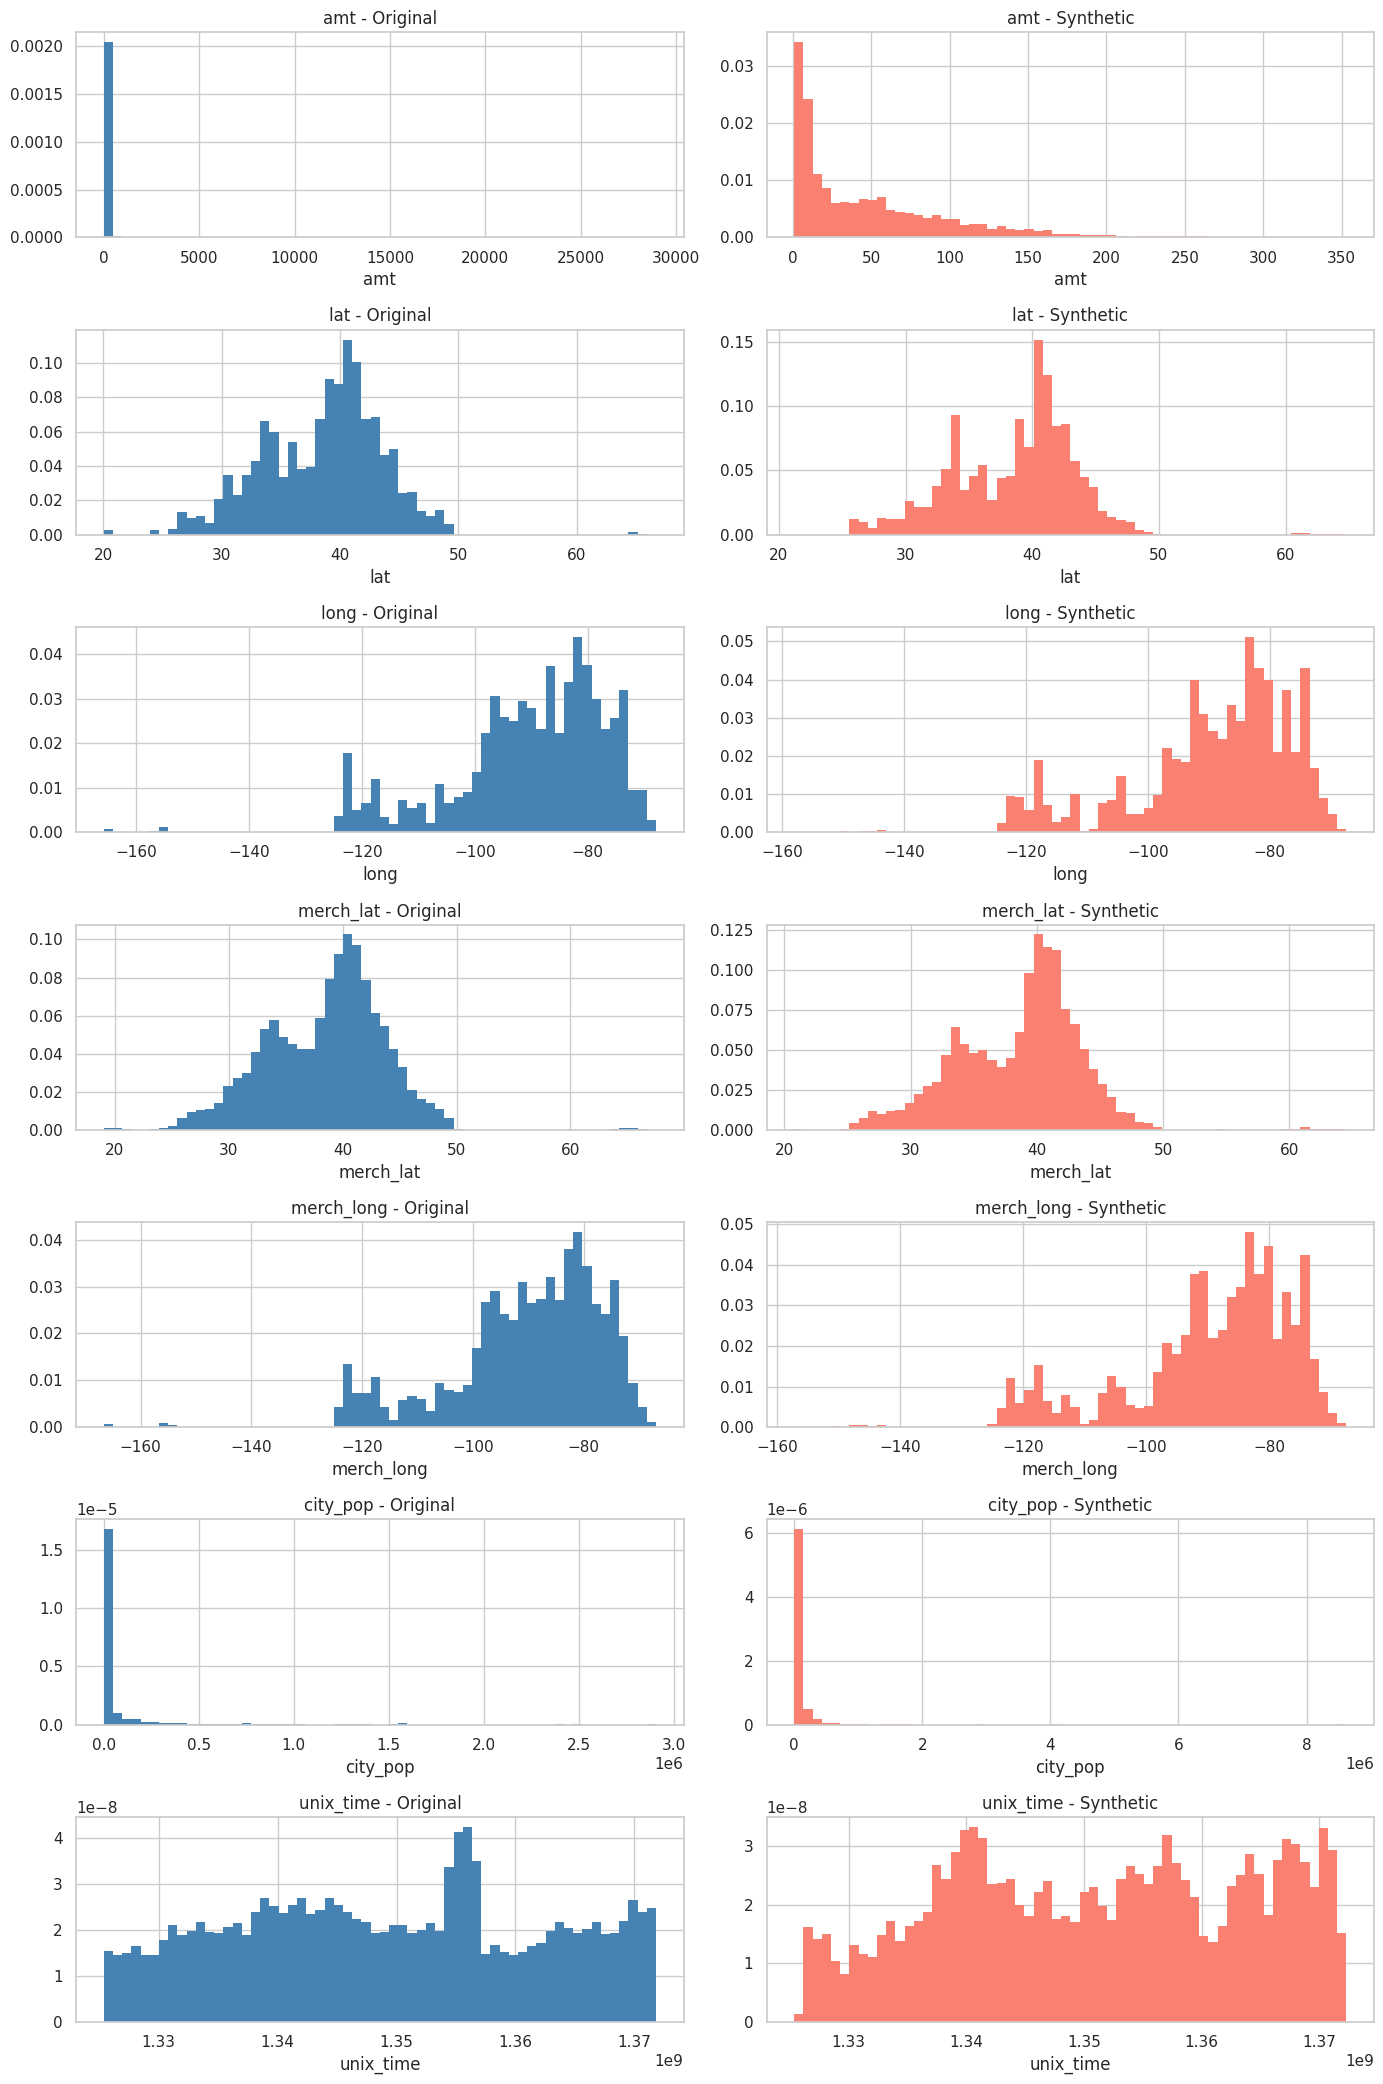

In [5]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    for j, (df, label) in enumerate([(orig, "Original"), (synt, "Synthetic")]):
        axes[i, j].hist(df[col].dropna(), bins=60, color="steelblue" if j == 0 else "salmon", edgecolor="none", density=True)
        axes[i, j].set_title(f"{col} - {label}")
        axes[i, j].set_xlabel(col)

plt.tight_layout()
plt.show()

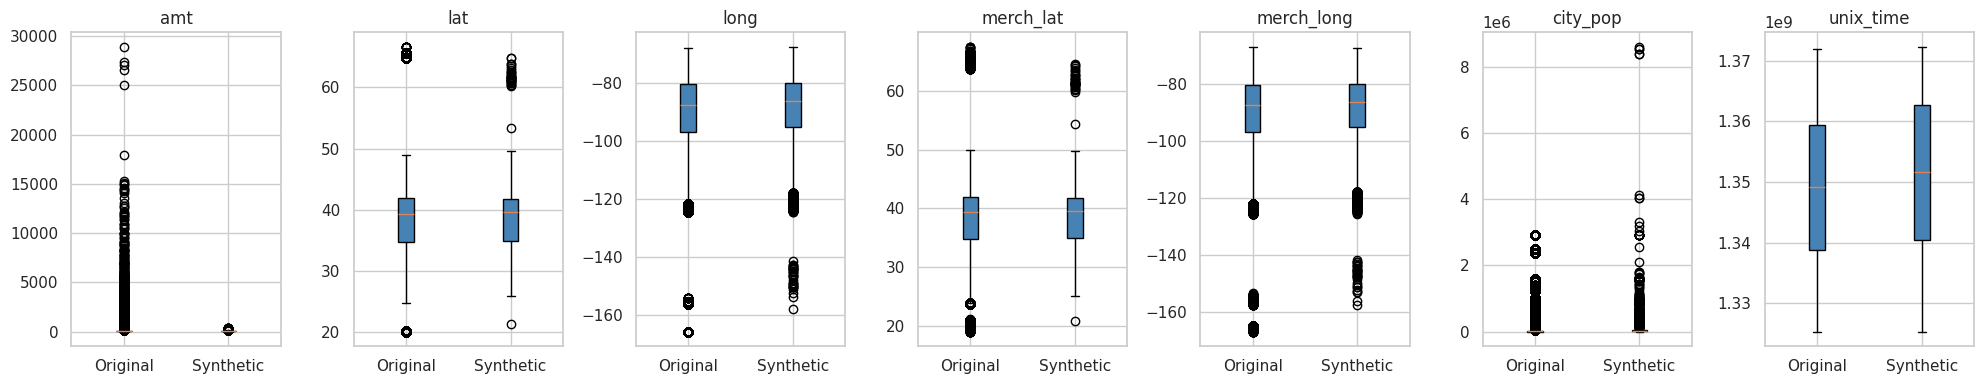

In [6]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))

for i, col in enumerate(num_cols):
    axes[i].boxplot(
        [orig[col].dropna(), synt[col].dropna()],
        tick_labels=["Original", "Synthetic"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue"),
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## 4. KS Test (Numerical)

> How statistically similar are the synthetic and original numerical distributions?

Two metrics per feature. TVD bins both distributions and measures how much probability mass differs (below 0.05 is good, below 0.10 acceptable, above that poor). KS test compares the empirical CDFs of both samples (a high statistic and low p-value means the two distributions are significantly different). TVD tells you how much they differ; KS tells you if that difference is statistically meaningful.

   feature    tvd  ks_stat  ks_p    quality
      long 0.1199   0.0684   0.0       poor
merch_long 0.1146   0.0647   0.0       poor
 unix_time 0.1129   0.0822   0.0       poor
       lat 0.0976   0.0421   0.0 acceptable
 merch_lat 0.0668   0.0293   0.0 acceptable
  city_pop 0.0312   0.2405   0.0       good
       amt 0.0090   0.1045   0.0       good


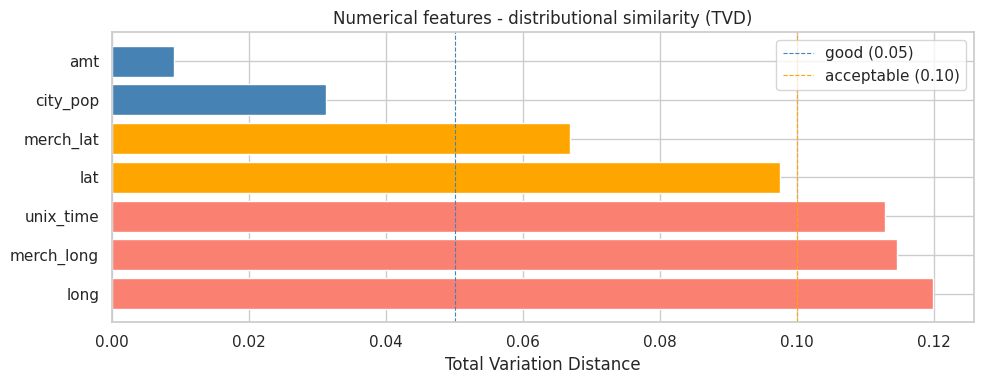

In [7]:
num_cols = ["amt", "lat", "long", "merch_lat", "merch_long", "city_pop", "unix_time"]

def tvd_numerical(s1, s2, bins=50):
    all_vals = pd.concat([s1, s2]).dropna()
    bin_edges = np.linspace(all_vals.min(), all_vals.max(), bins + 1)
    p, _ = np.histogram(s1.dropna(), bins=bin_edges, density=False)
    q, _ = np.histogram(s2.dropna(), bins=bin_edges, density=False)
    p = p / p.sum()
    q = q / q.sum()
    return round(0.5 * np.abs(p - q).sum(), 4)

num_results = []
for col in num_cols:
    tvd = tvd_numerical(orig[col], synt[col])
    ks_stat, ks_p = stats.ks_2samp(orig[col].dropna(), synt[col].dropna())
    num_results.append({
        "feature": col,
        "tvd": tvd,
        "ks_stat": round(ks_stat, 4),
        "ks_p": round(ks_p, 6),
        "quality": "good" if tvd < 0.05 else "acceptable" if tvd < 0.1 else "poor"
    })

num_df = pd.DataFrame(num_results).sort_values("tvd", ascending=False)
print(num_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["steelblue" if q == "good" else "orange" if q == "acceptable" else "salmon"
          for q in num_df["quality"]]
ax.barh(num_df["feature"], num_df["tvd"], color=colors)
ax.axvline(0.05, color="steelblue", linestyle="--", linewidth=0.8, label="good (0.05)")
ax.axvline(0.10, color="orange", linestyle="--", linewidth=0.8, label="acceptable (0.10)")
ax.set_xlabel("Total Variation Distance")
ax.set_title("Numerical features - distributional similarity (TVD)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Categorical Distributions

> Do the synthetic categorical features reproduce the same category frequencies as the originals?

Relative frequencies computed via value_counts(normalize=True) and shown as grouped bar charts. Makes it immediately visible if the model over/under-represents specific categories like certain states or job types.

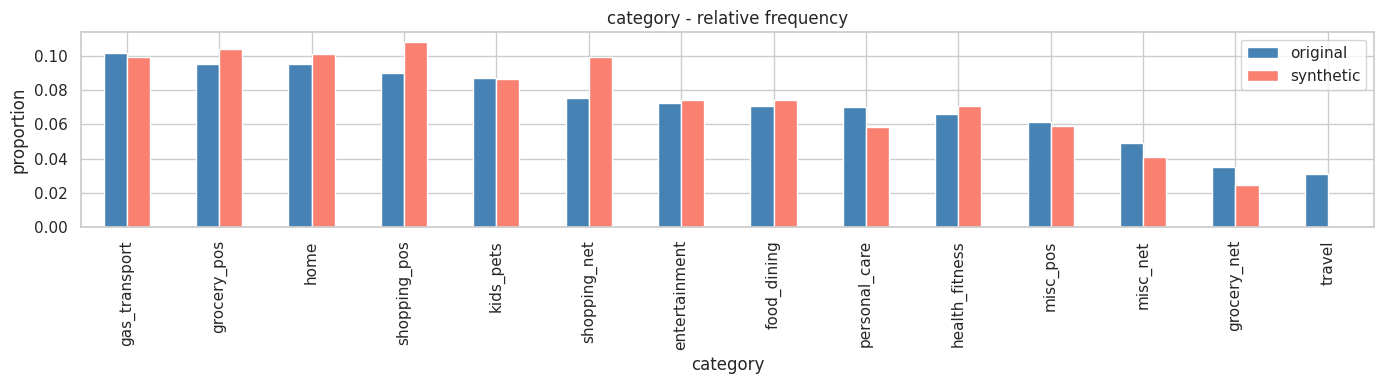

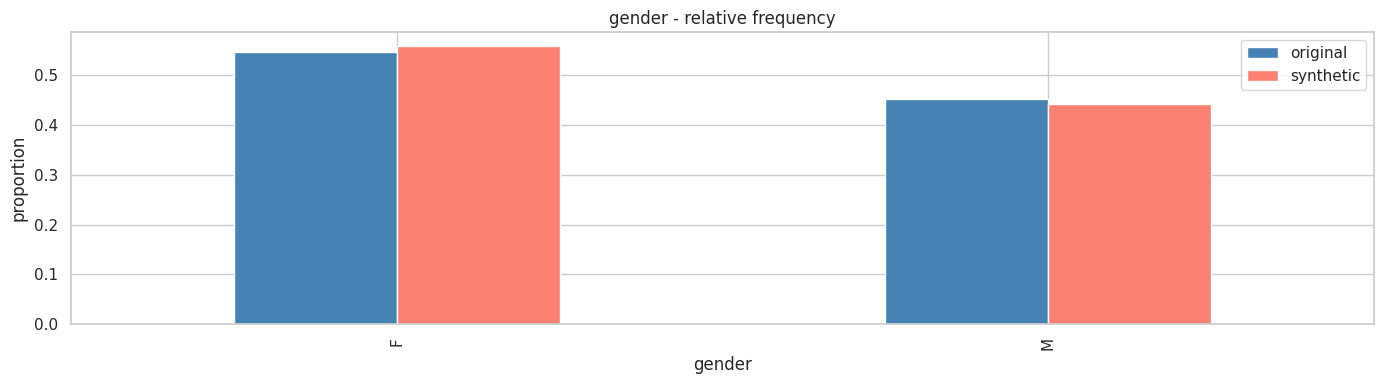

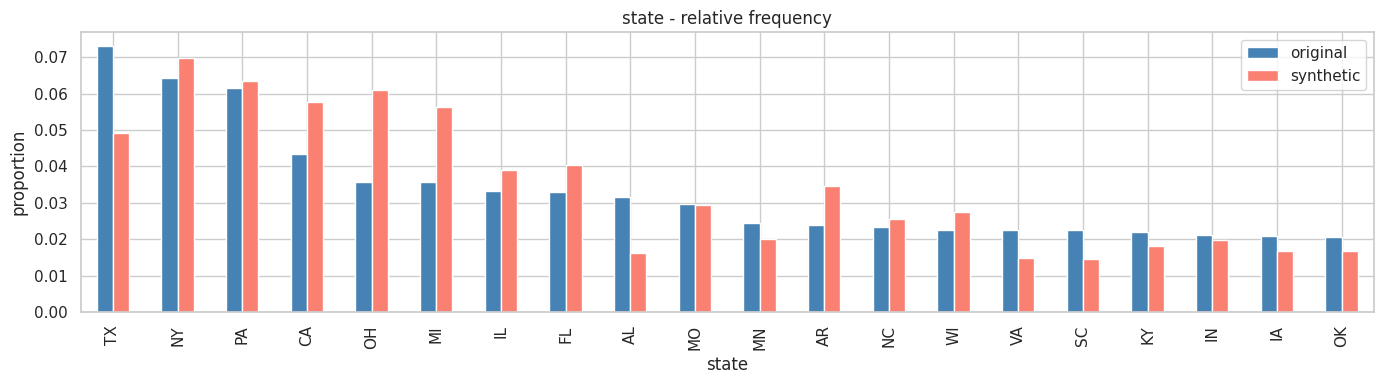

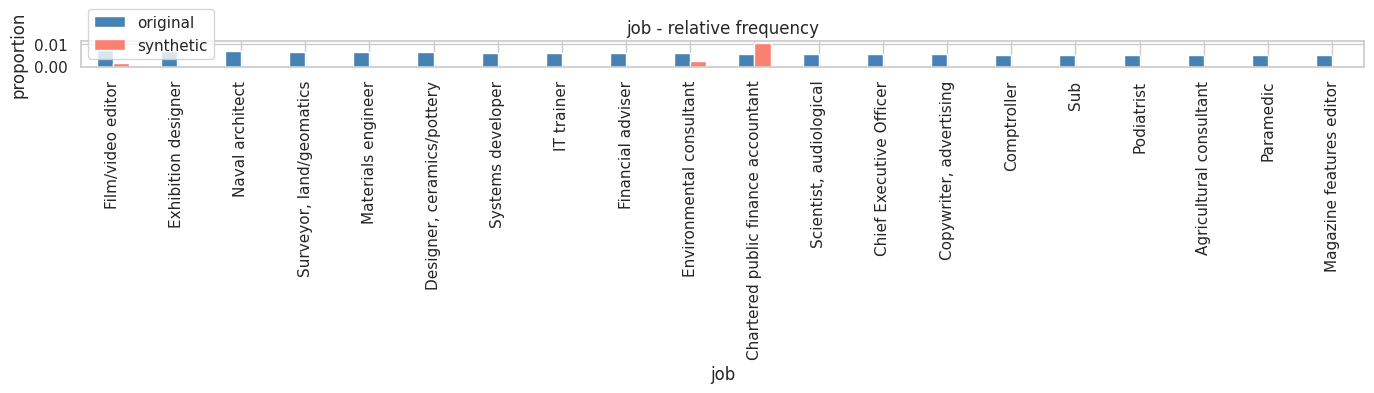

In [8]:
cat_cols = ["category", "gender", "state", "job"]

for col in cat_cols:
    freq_orig = orig[col].value_counts(normalize=True).rename("original")
    freq_synt = synt[col].value_counts(normalize=True).rename("synthetic")
    freq = pd.concat([freq_orig, freq_synt], axis=1).fillna(0).sort_values("original", ascending=False)

    top = freq.head(20)
    top.plot(kind="bar", figsize=(14, 4), title=f"{col} - relative frequency", color=["steelblue", "salmon"])
    plt.ylabel("proportion")
    plt.tight_layout()
    plt.show()

## 6. Chi-Square Test (Categorical)

> Are the differences in categorical distributions statistically significant, and how large is the effect?

Three metrics per feature. TVD works the same as section 4 but over discrete categories. Chi-Square compares original counts against scaled synthetic counts (a significant result means the distributions are statistically different). Cramér's V is an effect size derived from chi-square, ranging from 0 to 1, and unlike p-values it doesn't inflate with sample size.

 feature    tvd  cramers_v  chi2_p    quality
     job 0.9258  1286.3401     0.0       poor
   state 0.1646   448.7117     0.0       poor
category 0.0667  9866.0392     0.0 acceptable
  gender 0.0111     0.0223     0.0       good


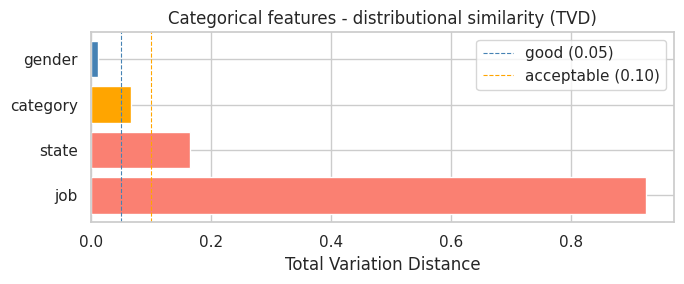

In [9]:
cat_cols = ["category", "gender", "state", "job"]

def tvd_categorical(s1, s2):
    cats = set(s1.dropna().unique()) | set(s2.dropna().unique())
    p = s1.value_counts(normalize=True).reindex(cats, fill_value=0)
    q = s2.value_counts(normalize=True).reindex(cats, fill_value=0)
    return round(0.5 * np.abs(p - q).sum(), 4)

cat_results = []
for col in cat_cols:
    tvd = tvd_categorical(orig[col], synt[col])
    cats = set(orig[col].dropna().unique()) | set(synt[col].dropna().unique())
    o = orig[col].value_counts().reindex(cats, fill_value=0)
    s = synt[col].value_counts().reindex(cats, fill_value=0)
    s_scaled = (s / s.sum()) * o.sum()
    s_smoothed = s_scaled + 1e-6
    s_smoothed = s_smoothed / s_smoothed.sum() * o.sum()
    chi2, chi2_p = stats.chisquare(f_obs=o, f_exp=s_smoothed)
    n = o.sum()
    k = len(cats)
    cramers_v = round(np.sqrt(chi2 / (n * (k - 1))), 4)
    cat_results.append({
        "feature": col,
        "tvd": tvd,
        "cramers_v": cramers_v,
        "chi2_p": round(chi2_p, 6),
        "quality": "good" if tvd < 0.05 else "acceptable" if tvd < 0.1 else "poor"
    })

cat_df = pd.DataFrame(cat_results).sort_values("tvd", ascending=False)
print(cat_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
colors = ["steelblue" if q == "good" else "orange" if q == "acceptable" else "salmon"
          for q in cat_df["quality"]]
ax.barh(cat_df["feature"], cat_df["tvd"], color=colors)
ax.axvline(0.05, color="steelblue", linestyle="--", linewidth=0.8, label="good (0.05)")
ax.axvline(0.10, color="orange", linestyle="--", linewidth=0.8, label="acceptable (0.10)")
ax.set_xlabel("Total Variation Distance")
ax.set_title("Categorical features - distributional similarity (TVD)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Fraud Analysis


> Does the synthetic data preserve the fraud signal?

Three checks: class balance compares fraud vs. legitimate proportions in both datasets; amount by fraud class checks whether synthetic data learned that fraudulent transactions tend to have different amounts; fraud rate by category verifies that the model reproduced which merchant categories are more fraud-prone.

          original  synthetic
is_fraud                     
0         0.994211        1.0
1         0.005789        NaN


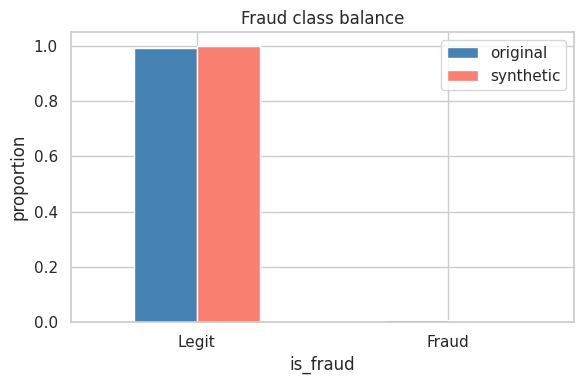

In [10]:
fraud_orig = orig["is_fraud"].value_counts(normalize=True)
fraud_synt = synt["is_fraud"].value_counts(normalize=True)
fraud_comp = pd.DataFrame({"original": fraud_orig, "synthetic": fraud_synt})
print(fraud_comp)

fraud_comp.plot(kind="bar", figsize=(6, 4), title="Fraud class balance", color=["steelblue", "salmon"])
plt.xticks([0, 1], ["Legit", "Fraud"], rotation=0)
plt.ylabel("proportion")
plt.tight_layout()
plt.show()

[Synthetic] No samples for fraud=1, skipping


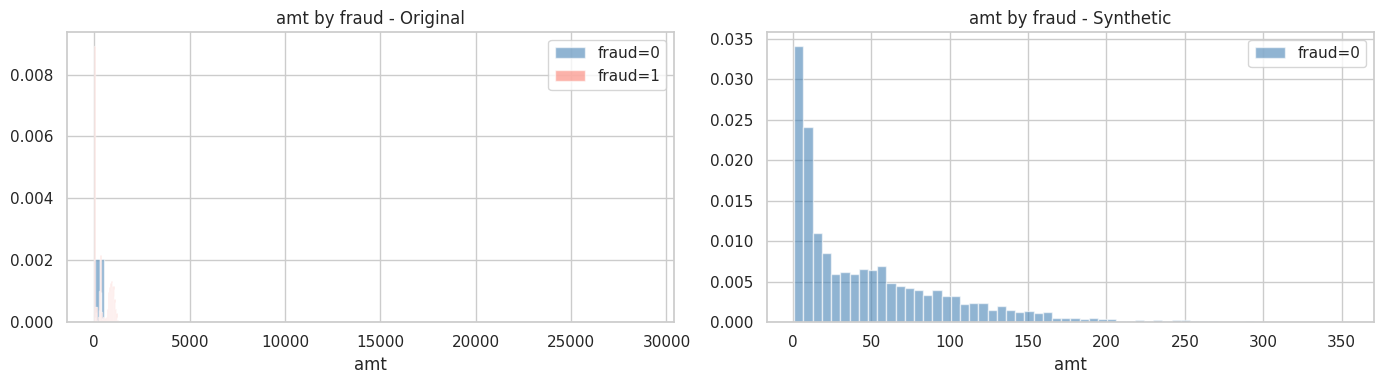

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (df, label) in zip(axes, [(orig, "Original"), (synt, "Synthetic")]):
    for fraud_val, color in [(0, "steelblue"), (1, "salmon")]:
        subset = df[df["is_fraud"] == fraud_val]["amt"].dropna()
        if subset.empty:
            print(f"[{label}] No samples for fraud={fraud_val}, skipping")
            continue
        ax.hist(subset, bins=60, alpha=0.6, density=True, color=color, label=f"fraud={fraud_val}")
    ax.set_title(f"amt by fraud - {label}")
    ax.set_xlabel("amt")
    ax.legend()

plt.tight_layout()
plt.show()

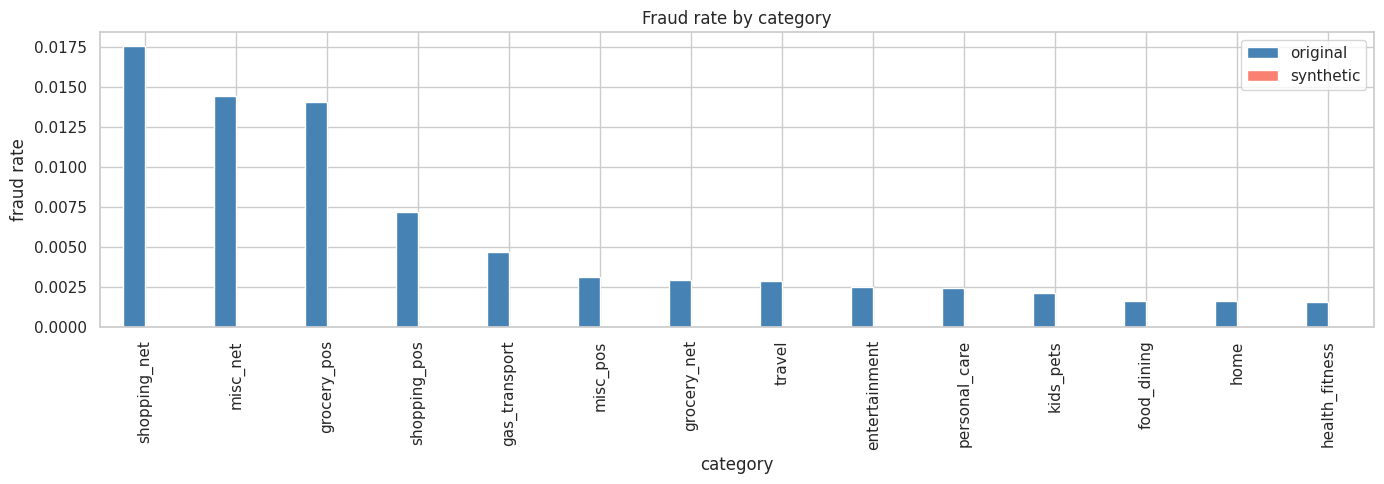

In [12]:
fraud_cat_orig = orig.groupby("category")["is_fraud"].mean().rename("original")
fraud_cat_synt = synt.groupby("category")["is_fraud"].mean().rename("synthetic")
fraud_cat = pd.concat([fraud_cat_orig, fraud_cat_synt], axis=1).fillna(0).sort_values("original", ascending=False)

fraud_cat.plot(kind="bar", figsize=(14, 5), title="Fraud rate by category", color=["steelblue", "salmon"])
plt.ylabel("fraud rate")
plt.tight_layout()
plt.show()

## 8. Correlation Heatmaps

> Does the synthetic data preserve the relationships between numerical features?

Pearson correlation matrices for both datasets, plus a third heatmap showing the absolute difference cell by cell. This checks whether the model learned inter-feature dependencies (not just individual distributions in isolation).

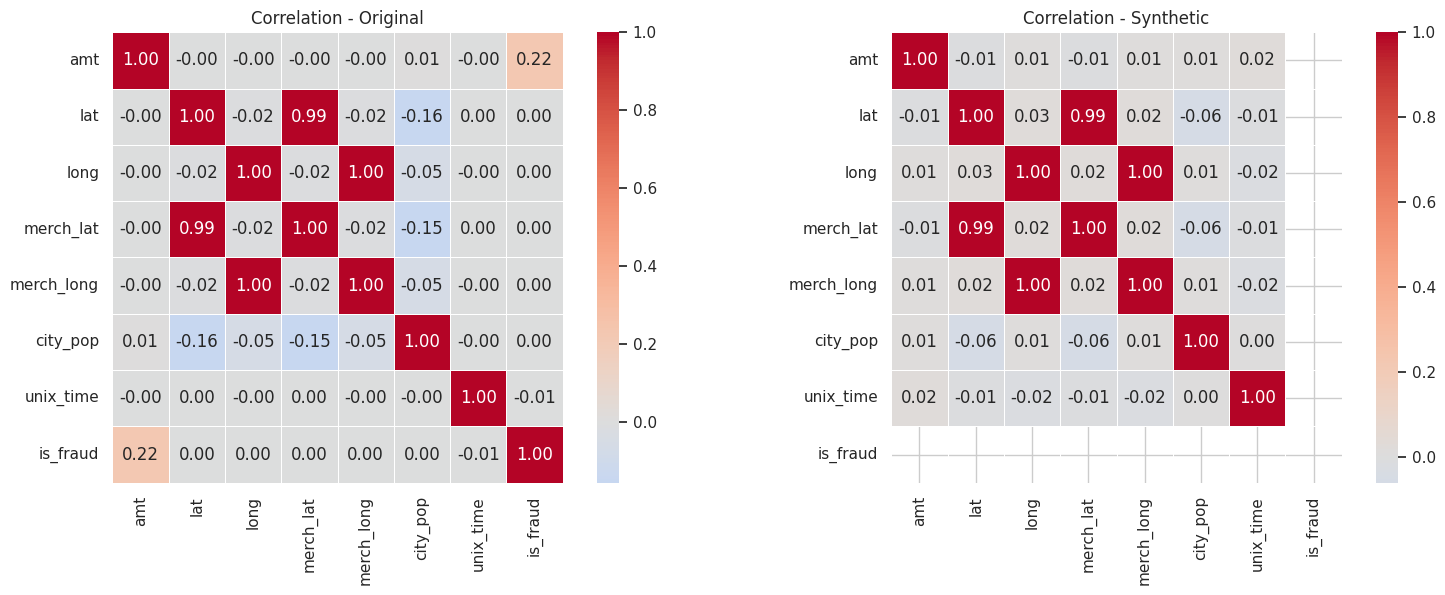

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df, label) in zip(axes, [(orig, "Original"), (synt, "Synthetic")]):
    corr = df[num_cols + ["is_fraud"]].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True, linewidths=0.5)
    ax.set_title(f"Correlation - {label}")

plt.tight_layout()
plt.show()

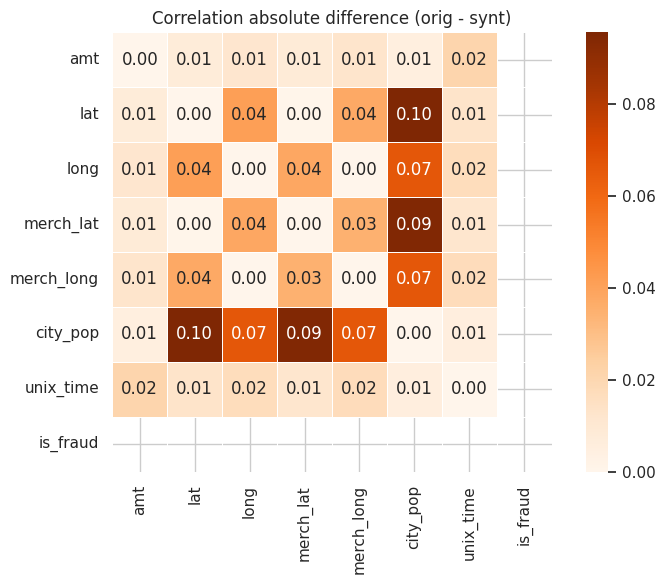

In [14]:
corr_orig = orig[num_cols + ["is_fraud"]].corr()
corr_synt = synt[num_cols + ["is_fraud"]].corr()
corr_diff = (corr_orig - corr_synt).abs()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_diff, annot=True, fmt=".2f", cmap="Oranges", square=True, linewidths=0.5)
plt.title("Correlation absolute difference (orig - synt)")
plt.tight_layout()
plt.show()

## 9. Geographic Distribution

> Does the synthetic data reproduce realistic spatial patterns?

Two checks: a scatter plot verifies that synthetic transactions fall within plausible geographic boundaries and not at invalid coordinates. The customer-to-merchant distance compares how far apart customers and merchants are in both datasets, checking whether the model preserved that realistic proximity relationship.

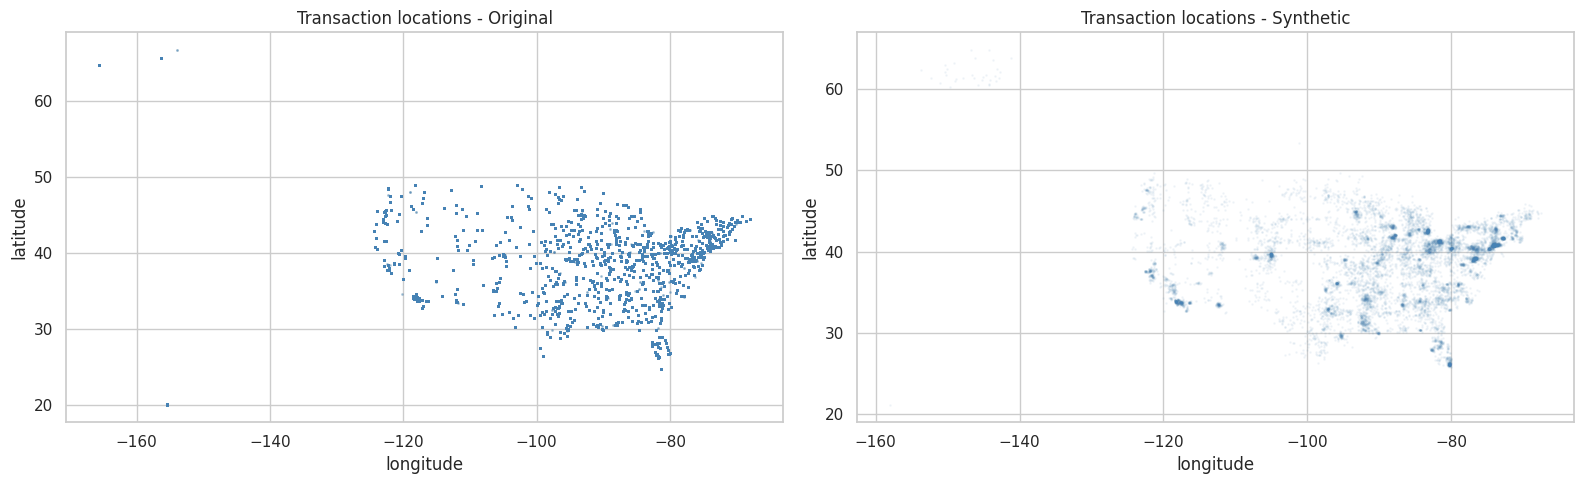

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df, label) in zip(axes, [(orig, "Original"), (synt, "Synthetic")]):
    ax.scatter(df["long"], df["lat"], alpha=0.05, s=1, c="steelblue")
    ax.set_title(f"Transaction locations - {label}")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

plt.tight_layout()
plt.show()

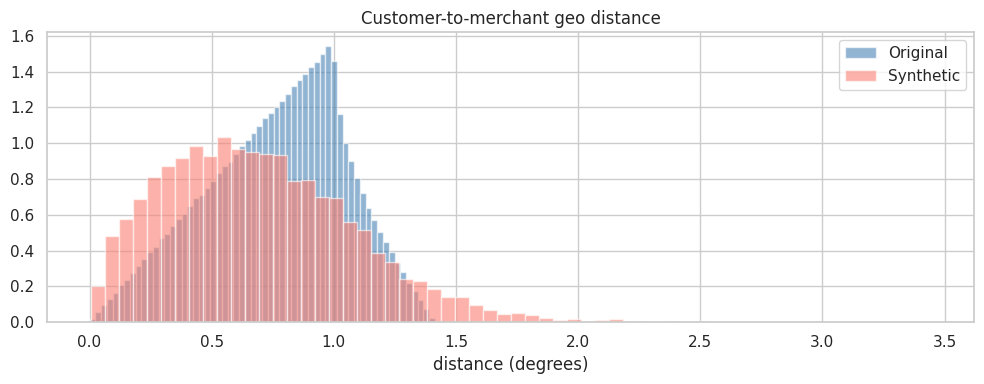

In [16]:
for df, label in [(orig, "Original"), (synt, "Synthetic")]:
    df["geo_distance"] = np.sqrt((df["lat"] - df["merch_lat"])**2 + (df["long"] - df["merch_long"])**2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(orig["geo_distance"].dropna(), bins=60, alpha=0.6, density=True, color="steelblue", label="Original")
ax.hist(synt["geo_distance"].dropna(), bins=60, alpha=0.6, density=True, color="salmon", label="Synthetic")
ax.set_title("Customer-to-merchant geo distance")
ax.set_xlabel("distance (degrees)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Temporal Analysis

> Does the synthetic data reproduce the original temporal patterns and fraud seasonality?

Extracts hour, day of week and month from the Unix timestamp, then runs two comparisons. Transaction volume by time slot checks whether activity peaks are preserved. Fraud rate by time slot checks whether the model learned when fraud is more likely to happen (e.g. at night or on weekends).

In [17]:
for df, label in [(orig, "Original"), (synt, "Synthetic")]:
    df["datetime"] = pd.to_datetime(df["unix_time"], unit="s")
    df["hour"] = df["datetime"].dt.hour
    df["dayofweek"] = df["datetime"].dt.dayofweek
    df["month"] = df["datetime"].dt.month

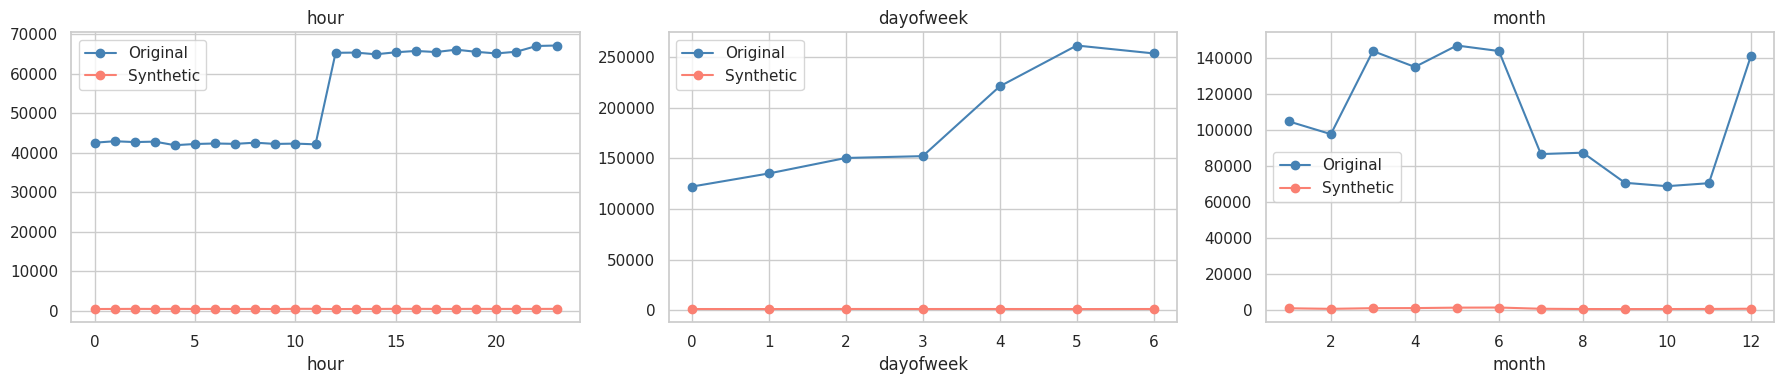

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
time_cols = ["hour", "dayofweek", "month"]

for ax, col in zip(axes, time_cols):
    orig[col].value_counts().sort_index().plot(ax=ax, label="Original", color="steelblue", marker="o")
    synt[col].value_counts().sort_index().plot(ax=ax, label="Synthetic", color="salmon", marker="o")
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

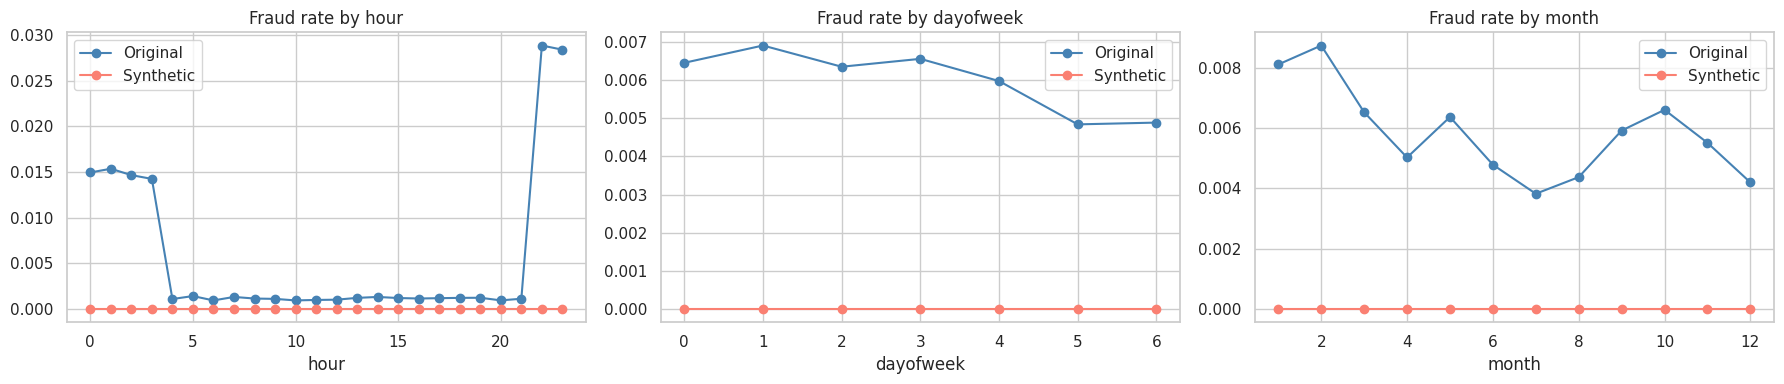

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, time_cols):
    fraud_rate_orig = orig.groupby(col)["is_fraud"].mean()
    fraud_rate_synt = synt.groupby(col)["is_fraud"].mean()
    fraud_rate_orig.plot(ax=ax, label="Original", color="steelblue", marker="o")
    fraud_rate_synt.plot(ax=ax, label="Synthetic", color="salmon", marker="o")
    ax.set_title(f"Fraud rate by {col}")
    ax.legend()

plt.tight_layout()
plt.show()

## 11. Privacy Check (Nearest Neighbor Distance)

> Is the synthetic data genuinely novel, or is it memorizing real records?

For each synthetic record, the nearest original record is found in a standardized feature space. A baseline is then computed by finding each original record's nearest other original (representing the natural density of the real data). The privacy ratio divides the two mean distances: a ratio near or above 1 means synthetic points are as far from real ones as real points are from each other, which is good. Well below 1 suggests memorization. Records closer than 0.01 are flagged as likely exact copies.

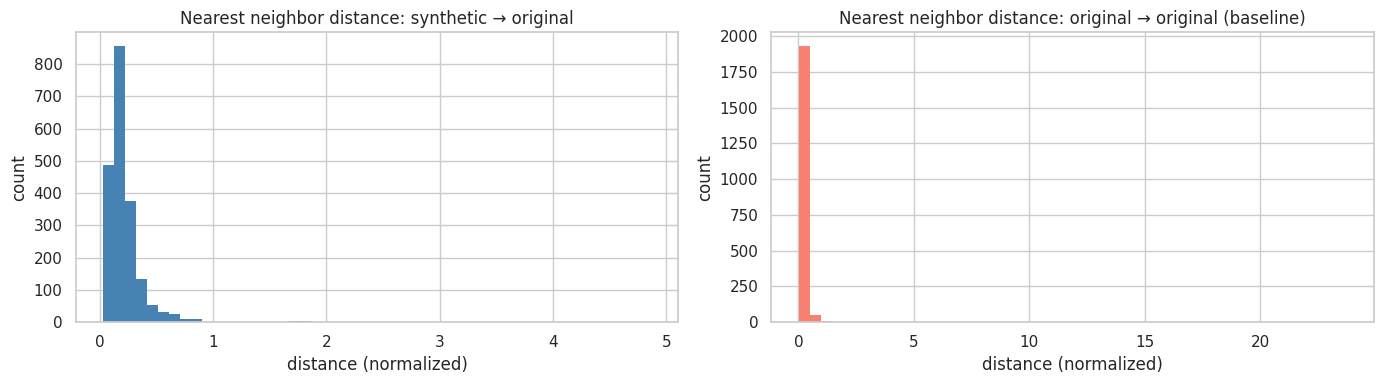

Mean NN distance (synt→orig) : 0.2247
Mean NN distance (orig→orig) : 0.1968
Ratio (privacy score)        : 1.1417
% exact copies               : 0.00%


In [20]:
sample_cols = ["amt", "lat", "long", "merch_lat", "merch_long", "city_pop"]
sample_size = 2000

orig_sample = orig[sample_cols].dropna().sample(sample_size, random_state=42)
synt_sample = synt[sample_cols].dropna().sample(min(sample_size, len(synt)), random_state=42)

scaler = StandardScaler()
orig_scaled = scaler.fit_transform(orig_sample)
synt_scaled = scaler.transform(synt_sample)

nn = NearestNeighbors(n_neighbors=1).fit(orig_scaled)
distances, _ = nn.kneighbors(synt_scaled)

nn_baseline = NearestNeighbors(n_neighbors=2).fit(orig_scaled)
dist_baseline, _ = nn_baseline.kneighbors(orig_scaled)
baseline_dist = dist_baseline[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(distances.flatten(), bins=50, color="steelblue", edgecolor="none")
axes[0].set_title("Nearest neighbor distance: synthetic → original")
axes[0].set_xlabel("distance (normalized)")
axes[0].set_ylabel("count")

axes[1].hist(baseline_dist, bins=50, color="salmon", edgecolor="none")
axes[1].set_title("Nearest neighbor distance: original → original (baseline)")
axes[1].set_xlabel("distance (normalized)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

privacy_ratio = distances.mean() / baseline_dist.mean()

print(f"Mean NN distance (synt→orig) : {distances.mean():.4f}")
print(f"Mean NN distance (orig→orig) : {baseline_dist.mean():.4f}")
print(f"Ratio (privacy score)        : {privacy_ratio:.4f}")
print(f"% exact copies               : {(distances.flatten() < 0.01).mean()*100:.2f}%")